## Calibration Results

#### SELECT MODEL ID / RUN NAME

In [1]:
# Corresponds to the desired model for displaying results

run_name = '20250627_150251_densenet121'
run_name = '20250717_184244_densenet121'

### Notebook & Data Set-Up

In [2]:
# Imports
import os
from collections import defaultdict

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

from sklearn.metrics import *
from sklearn.preprocessing import label_binarize

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
# Paths
data_directory = '/data/zooplankton_data'
results_directory = '/home/bushra/Analysis_zooplankton/'

weights_path = os.path.join(results_directory, 'weights', run_name + '.pth')
predictions_path = os.path.join(results_directory, 'predictions', run_name + '.pth')
metadata_path = os.path.join(results_directory, 'environment', run_name + '.pth')

In [4]:
# Load predictions
predictions = torch.load(predictions_path, map_location = torch.device('cpu'))
y_true = predictions[0].numpy()
y_pred = predictions[2].numpy()
y_prob = predictions[1].numpy()

# Load environment/metadata variables
metadata = torch.load(metadata_path, weights_only = False)
model_id, model_name = metadata['model_id'], metadata['model_name']
classes, class_map_orig = metadata['classes'], metadata['class_map']
train_metrics = metadata['train_metrics']
hyperparameters = metadata['hyperparameters']
test_loader = metadata['test_loader']
# image_transforms = metadata['image_transforms']

#### Merge Classes

In [5]:
# UPDATE HERE
merge_classes = True

In [6]:
# Define function to merge classes

def reorder_and_merge_classes(class_map, y_true, y_pred, y_prob, to_merge):

    class_map_rev = {v: k for k, v in class_map.items()} # Inverse class map

    # Create new class map with main classes + other
    to_keep = sorted([cls for cls in class_map if cls not in to_merge])
    new_class_map = {cls: idx for idx, cls in enumerate(to_keep)}

    other_index = len(to_keep)
    new_class_map['Other'] = other_index

    # Map old indices to new indices
    orig_max_index = max(class_map.values())
    orig_to_new_map = np.zeros(orig_max_index + 1, dtype = int)

    for orig_idx, cls in class_map_rev.items():
        if cls in to_merge:
            orig_to_new_map[orig_idx] = other_index
        else:
            orig_to_new_map[orig_idx] = new_class_map[cls]

    # Map labels
    new_y_true = orig_to_new_map[y_true]
    new_y_pred = orig_to_new_map[y_pred]

    # Map prediction probabilities
    n_samples = y_prob.shape[0]
    new_n_classes = len(new_class_map)
    new_y_prob = np.zeros((n_samples, new_n_classes))
    
    for orig_idx, cls in class_map_rev.items():
        new_idx = new_class_map['Other'] if cls in to_merge else new_class_map[cls]
        new_y_prob[:, new_idx] += y_prob[:, orig_idx]

    # Need to normalize due to floating-point precision
    y_prob_sums = new_y_prob.sum(axis = 1, keepdims = True)
    new_y_prob = new_y_prob / y_prob_sums

    return new_class_map, new_y_true, new_y_pred, new_y_prob

In [7]:
# Merge classes
to_merge = ['Bubbles', 'Floc_1', 'Floc_2', 'LargeZ-1', 'Nauplii', 'Sididae', 'TooSmall']

if merge_classes:
    class_map, y_true, y_pred, y_prob = reorder_and_merge_classes(class_map_orig, y_true, y_pred, y_prob, to_merge)
else:
    class_map = class_map_orig
    
class_map_rev = {v: k for k, v in class_map.items()}
classes = list(class_map.keys())

NUM_CLASSES = len(classes)

### Model Train Parameters

In [8]:
print(f'Selected Model: {model_name} (ID: {model_id})')
print('\nClasses:\n ' + '\n '.join(f'{cln}: {clid}' for cln, clid in class_map.items())) # New classes, but model trained on orig classes
print('\nTraining Parameters:\n ' + '\n '.join(f'{p}: {pv}' for p, pv in hyperparameters.items()))

Selected Model: densenet121 (ID: 20250717_184244)

Classes:
 Bosmina_1: 0
 Calanoid_1: 1
 Chironomid: 2
 Chydoridae: 3
 Cyclopoid_1: 4
 Daphnia: 5
 Herpacticoida: 6
 Other: 7

Training Parameters:
 loss_fn: {'type': 'CrossEntropyLoss', 'weights': tensor([0.0713, 0.0713, 0.0713, 0.0713, 0.0718, 0.0713, 0.0715, 0.0713, 0.0724,
        0.0713, 0.0713, 0.0714, 0.0715, 0.0713])}
 optimizer: Adam
 lr: 0.0005
 epochs: 80
 scheduler: {'type': 'CosineAnnealingLR', 'T_max': 50}
 early_stopping: {'patience': 15, 'delta': 0.005}
 batch_size: 64


### Calibration

#### Define Functions

In [9]:
def get_gm_specifics(real_labels, probs_labels, gm_index, n_classes):

    """
    Reduces multiclass problem to binary problem for the specified class.
    Positive class is gm_index and negative class is all other classes.

    Args:
        real_labels: True class labels. (N, )
        probs_labels: Predicted class probabilities. (N, n_classes)
        gm_index: Specified class to consider as positive.
        n_classes: Number of classes in original multiclass problem.

    Returns:
        gm_vs_all: Binary label vector, where 1 if true class is gm_index and 0 otherwise. (N, )
        preds_gm: Vector containing class probabilities for specified gm_index class. (N, )
    """

    if not torch.is_tensor(real_labels):
        real_labels = torch.tensor(real_labels)
    if not torch.is_tensor(probs_labels):
        probs_labels = torch.tensor(probs_labels)
    
    # Convert to numpy arrays
    all_reals = real_labels.view(-1)  # shape (N,)
    all_probs = probs_labels.view(-1, n_classes)  # shape (N, n_classes)
    

    # Binary labels: 1 if true class is gm_index, else 0
    gm_vs_all = (all_reals == gm_index).int()

    # Predicted probabilities for gm_index
    preds_gm = all_probs[:, gm_index]
    
    return gm_vs_all.tolist(), preds_gm.tolist()   

#### Histogram of Probabilities

In [10]:
marginal_labels = []
marginal_probs = []

for i in range(NUM_CLASSES):
    curr_labels, curr_preds = get_gm_specifics(
    real_labels = y_true, 
    probs_labels = y_prob,
    gm_index = i, 
    n_classes = NUM_CLASSES)

    marginal_labels.append(curr_labels)
    marginal_probs.append(curr_preds) 

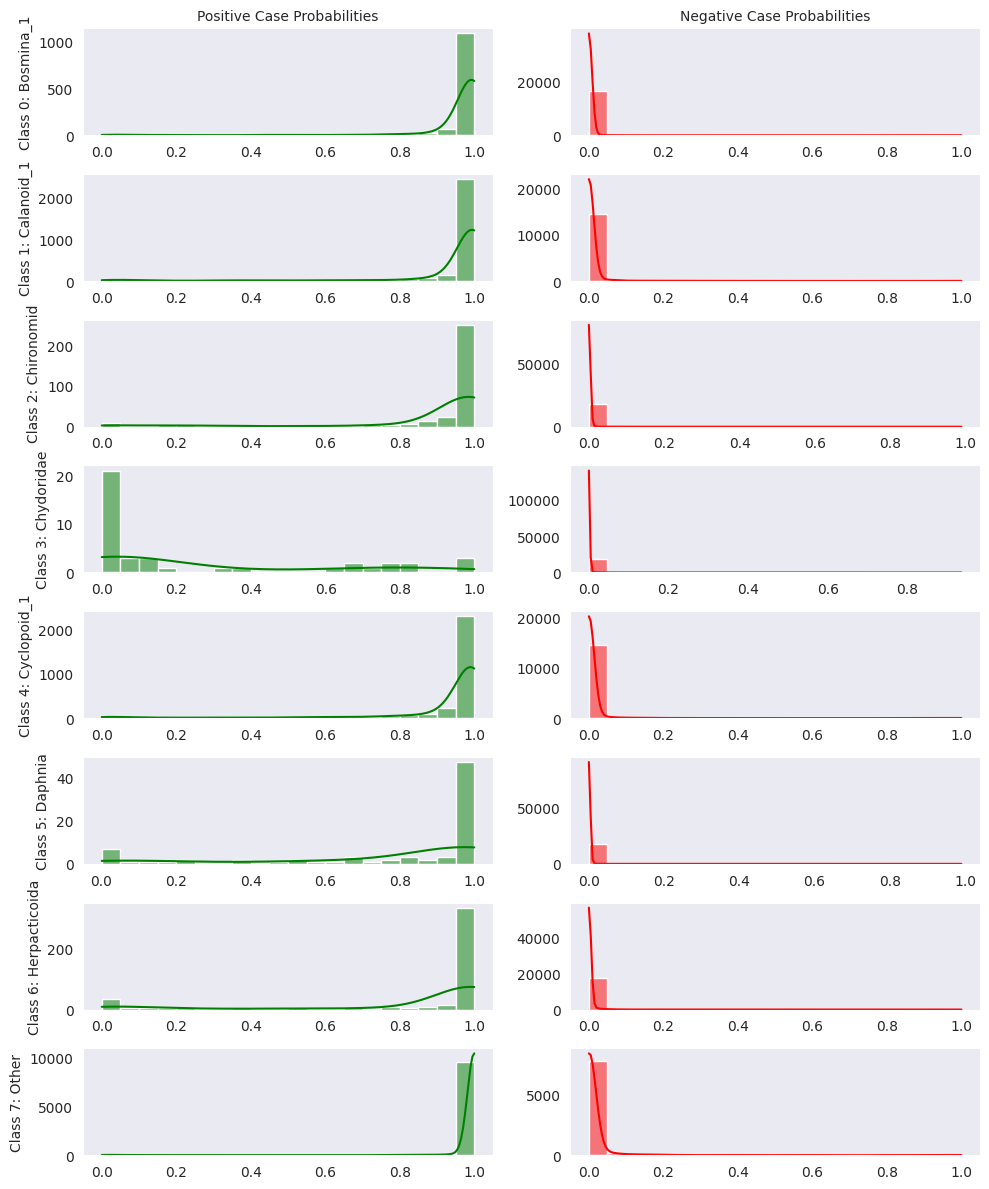

In [11]:
sns.set_style('dark')
fig, axs = plt.subplots(NUM_CLASSES, 2, figsize = (10, NUM_CLASSES * 1.5))

for i in range(NUM_CLASSES):
    positive_cases = np.where(np.array(marginal_labels[i]) == 1)
    positive_probs = np.array(marginal_probs[i])[positive_cases]

    negative_cases = np.where(np.array(marginal_labels[i]) == 0)
    negative_probs = np.array(marginal_probs[i])[negative_cases]

    sns.histplot(positive_probs, bins=20, ax=axs[i, 0], color='green', kde=True)
    sns.histplot(negative_probs, bins=20, ax=axs[i, 1], color='red', kde=True)

    axs[i, 0].set_ylabel(f'Class {i}: {class_map_rev[i]}', fontsize=10)
    axs[i, 0].set_xlabel('')
    axs[i, 1].set_ylabel('')
    axs[i, 1].set_xlabel('')

    if i == 0:
        axs[i, 0].set_title('Positive Case Probabilities', fontsize=10)
        axs[i, 1].set_title('Negative Case Probabilities', fontsize=10)

plt.tight_layout()
plt.show()

#### Calibration Curve

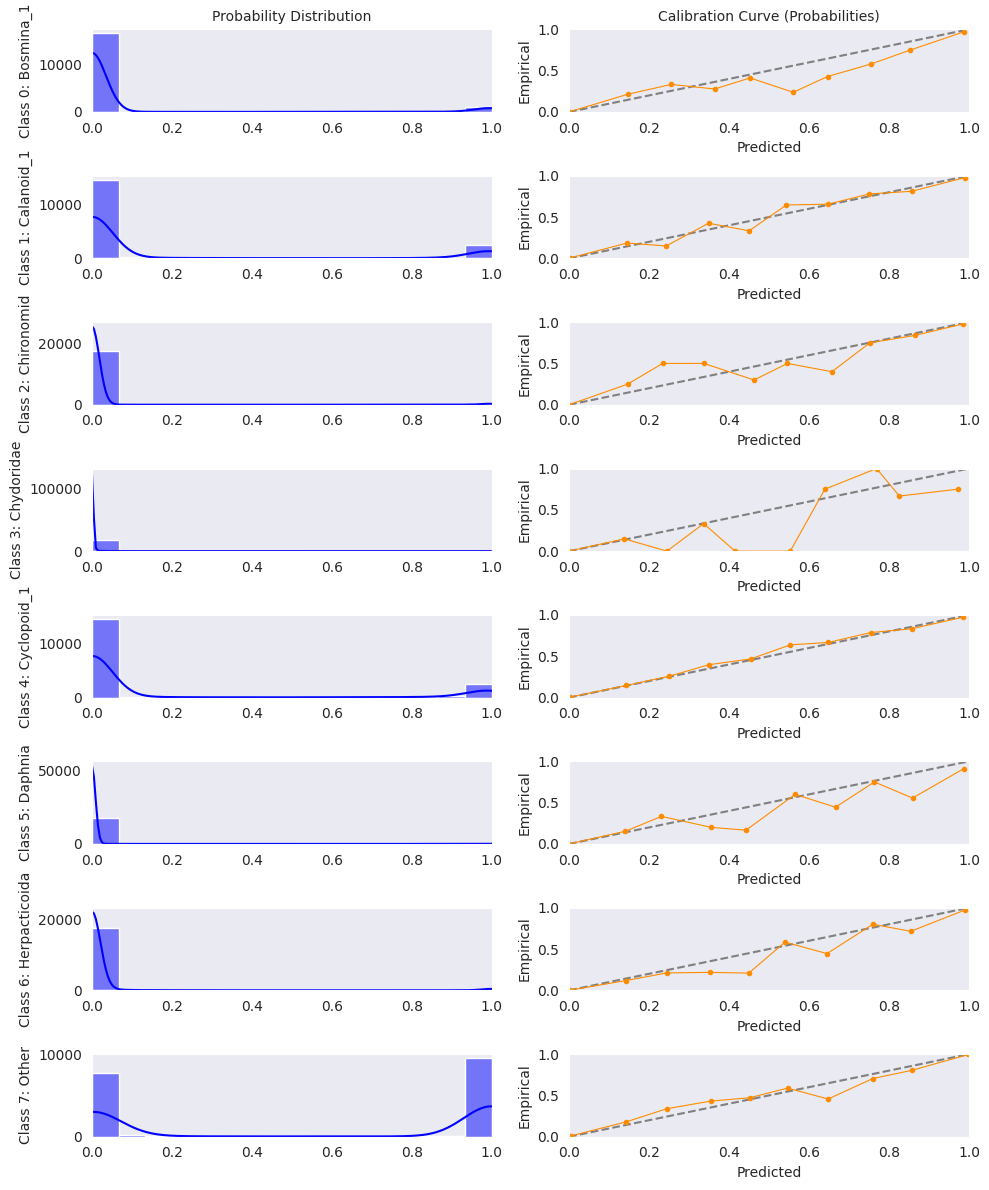

In [12]:
from sklearn.calibration import calibration_curve

fig, axs = plt.subplots(NUM_CLASSES, 2, figsize = (10, NUM_CLASSES * 1.5))

for i in range(NUM_CLASSES):

    prob_true, prob_pred = calibration_curve(
        marginal_labels[i], 
        marginal_probs[i], 
        n_bins = 10,
        strategy='uniform',
        pos_label = 1)


     # Left: histogram of predicted probabilities
    sns.histplot(marginal_probs[i], bins=15, kde=True, color='blue', ax=axs[i,0])
    axs[i,0].set_xlim(0,1)
    axs[i,0].set_ylabel(f'Class {i}: {class_map_rev[i]}', fontsize=10)

    # Right: calibration curve
    axs[i,1].plot([0, 1], [0, 1], linestyle='--', color='gray')
    axs[i,1].plot(prob_pred, prob_true, marker='o',  markersize=3, linewidth=0.8, color='darkorange')
    axs[i,1].set_xlim(0,1)
    axs[i,1].set_ylim(0,1)
    axs[i,1].set_xlabel("Predicted")
    axs[i,1].set_ylabel("Empirical")

    if i == 0:
        axs[i, 0].set_title('Probability Distribution', fontsize=10)
        axs[i, 1].set_title('Calibration Curve (Probabilities)', fontsize=10)

plt.tight_layout()
plt.show()


#### Expected Calibration Error

In [13]:
from torch import tensor
from torchmetrics.classification import BinaryCalibrationError

metric = BinaryCalibrationError(n_bins=10, norm='l2')
ece_values = []
for i in range(NUM_CLASSES):
    preds = tensor(marginal_probs[i])
    target = tensor(marginal_labels[i])
    
    ece_values.append(metric(preds, target))

ece_values

[tensor(0.0173),
 tensor(0.0142),
 tensor(0.0111),
 tensor(0.0111),
 tensor(0.0088),
 tensor(0.0114),
 tensor(0.0133),
 tensor(0.0144)]

#### Scaling

In [14]:
class MultiLabelTempScaler(nn.Module):

    def __init__(self,nlabels):
        super().__init__()
        self.temperatures = nn.Parameter(torch.ones(nlabels))
        #self.biases = nn.Parameter(torch.ones(nlabels))
        
    def forward(self,logits):
        return (
            #self.biases + 
            logits/self.temperatures#.unsqueeze(0)
        )

In [15]:
import torch.optim as optim 
import torch.nn.functional as F

scaler = MultiLabelTempScaler(14).to(device)
optimizer = optim.LBFGS(scaler.parameters(), lr=0.1)  

In [16]:
# Load model
model = models.densenet121(weights=None)
model.classifier = torch.nn.Linear(model.classifier.in_features, 14)

weights = torch.load(weights_path, map_location = device)

model.load_state_dict(weights)
model.to(device);

In [35]:
logits_list = []
labels_list = []
temps = []
losses = []

dataloader = test_loader

for batch,(X, y) in enumerate(dataloader):
        X = X.to(device,dtype = torch.float)
        y = y.to(device,dtype = torch.long)
        model.eval()
        with torch.no_grad():
            logits_list.append(model(X))
            labels_list.append(y)
           
            
# Create tensors 
logits_list = torch.cat(logits_list).to(device)
labels_list = torch.cat(labels_list).long().to(device)

labels_ohe = torch.zeros(len(y_pred), 14).to(device)
labels_ohe[range(labels_ohe.shape[0]), labels_list]=1

def _eval():
    scaled_logits = scaler(logits_list).to(device)
    labels_ohe.to(device)

    loss = F.cross_entropy(scaled_logits, labels_list, reduction = 'none')
    loss.backward()
    
    return loss

optimizer.step(_eval)

RuntimeError: grad can be implicitly created only for scalar outputs

In [29]:
print(scaler.temperatures.data)
#print(scaler.biases.data)

tensor([ 8.1139e+12,  1.2878e+13,  3.1411e+13,  7.3521e+11,  1.4795e+13,
        -3.8283e+13,  2.6899e+11,  1.0797e+14, -8.0690e+11,  3.5872e+13,
         2.8456e+13, -1.7296e+12, -9.5192e+11,  8.9652e+12], device='cuda:0')


In [30]:
def get_predictions_scaler(model,image):
   
    out = scaler(model(image))
    #print(out[0])
    #out2 = model(image)
    #print(out2[0])

    probs = torch.sigmoid(out)
    preds = torch.zeros_like(probs)  
    topk = torch.topk(probs, k=2, dim=1)  
    topk_indices = topk.indices   
    preds.scatter_(1, topk_indices, 1.0)    
     
    return preds, probs


def test_loop_scaler(model,dataloader,device):
    
    model.to(device)
    model.eval()
   
    real_labels = []
    pred_labels = []
    probs_labels = []
    with torch.no_grad():
        for batch,(X, y) in enumerate(dataloader):
                X = X.to(device,dtype = torch.float)
                y = y.to(device,dtype = torch.float)
                preds, probs = get_predictions_scaler(model,X)
                pred_labels.append(preds)
                probs_labels.append(probs)
                real_labels.append(y)
            
    return real_labels, pred_labels, probs_labels    

In [31]:
y_true_as, y_pred_as, y_prob_as = test_loop_scaler(
    model = model,
    dataloader = test_loader,
    device = device
)

y_true_as = torch.cat(y_true_as)
y_pred_as = torch.cat(y_pred_as, dim = 0)
y_prob_as = torch.cat(y_prob_as, dim = 0)

In [32]:
y_pred_as_ignore = torch.argmax(y_pred_as, dim = 1) # this is incorrect, do not use!! only so the merge function runs properly

if merge_classes:
    _, y_true_as, _, y_prob_as = reorder_and_merge_classes(
        class_map_orig, y_true_as.int().cpu().numpy(), y_pred_as_ignore.int().cpu().numpy(), y_prob_as.cpu().numpy(), to_merge)


In [33]:
# re calculate logits
marginal_labels_scaling = []
marginal_probs_scaling = []

for i in range(NUM_CLASSES):
    #print(i)
    curr_labels, curr_preds = get_gm_specifics(
    real_labels = y_true_as, 
    probs_labels = y_prob_as,
    gm_index = i, 
    n_classes = NUM_CLASSES)

    marginal_labels_scaling.append(curr_labels)
    marginal_probs_scaling.append(curr_preds)

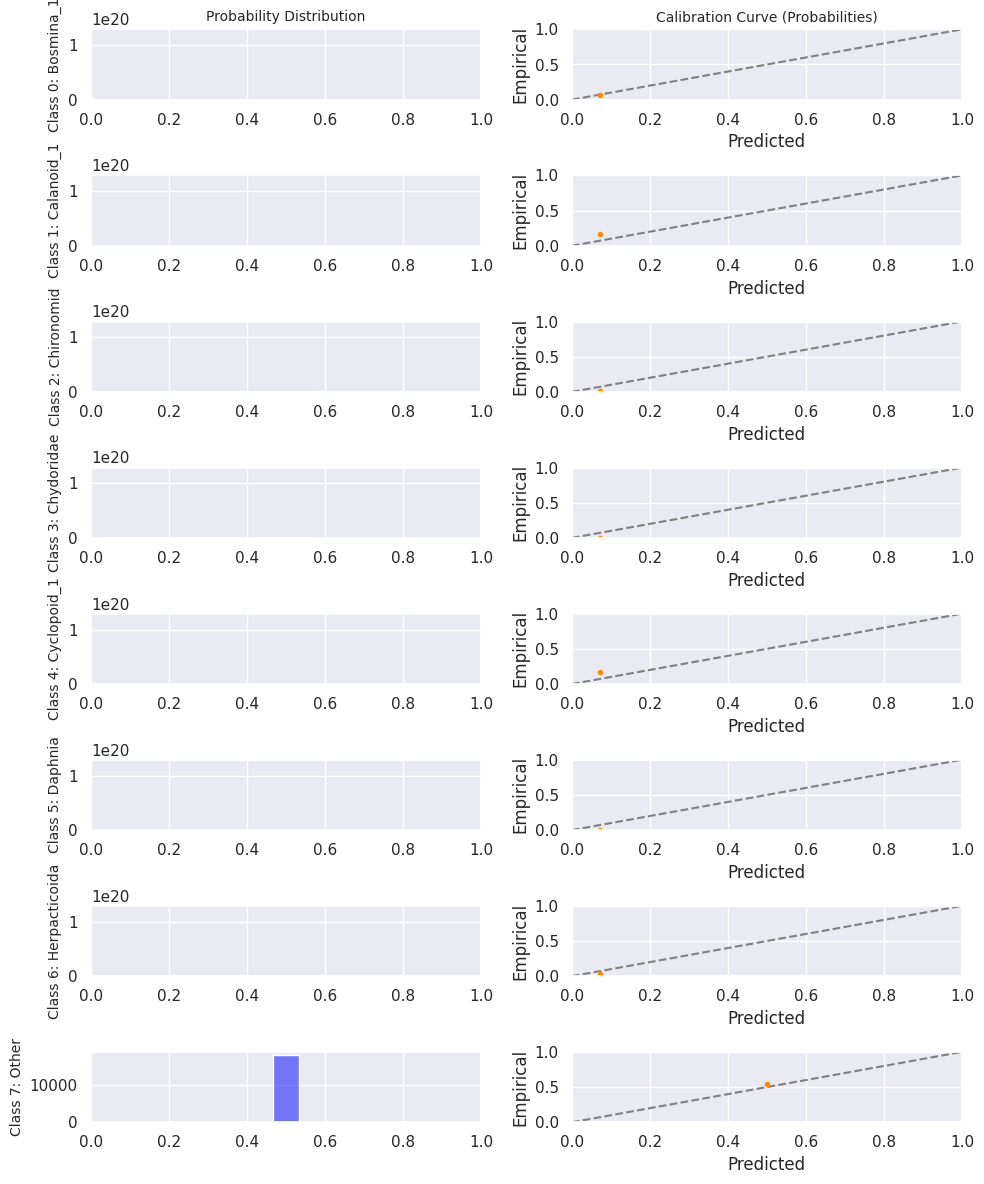

In [34]:
fig, axs = plt.subplots(NUM_CLASSES, 2, figsize = (10, NUM_CLASSES * 1.5))

for i in range(NUM_CLASSES):

    prob_true, prob_pred = calibration_curve(
        marginal_labels_scaling[i], 
        marginal_probs_scaling[i], 
        n_bins = 10,
        strategy='uniform',
        pos_label = 1)


     # Left: histogram of predicted probabilities
    sns.histplot(marginal_probs_scaling[i], bins=15, kde=True, color='blue', ax=axs[i,0])
    axs[i,0].set_xlim(0,1)
    axs[i,0].set_ylabel(f'Class {i}: {class_map_rev[i]}', fontsize=10)

    # Right: calibration curve
    axs[i,1].plot([0, 1], [0, 1], linestyle='--', color='gray')
    axs[i,1].plot(prob_pred, prob_true, marker='o',  markersize=3, linewidth=0.8, color='darkorange')
    axs[i,1].set_xlim(0,1)
    axs[i,1].set_ylim(0,1)
    axs[i,1].set_xlabel("Predicted")
    axs[i,1].set_ylabel("Empirical")

    if i == 0:
        axs[i, 0].set_title('Probability Distribution', fontsize=10)
        axs[i, 1].set_title('Calibration Curve (Probabilities)', fontsize=10)

plt.tight_layout()
plt.show()


In [24]:
ece_values_scaling = []

for i in range(NUM_CLASSES):
    preds = tensor(marginal_probs_scaling[i])
    target = tensor(marginal_labels_scaling[i])
    
    ece_values_scaling.append(metric(preds, target))

print(ece_values)
print(ece_values_scaling)


[tensor(0.0173), tensor(0.0142), tensor(0.0111), tensor(0.0111), tensor(0.0088), tensor(0.0114), tensor(0.0133), tensor(0.0144)]
[tensor(0.1064), tensor(0.1309), tensor(0.0496), tensor(0.0546), tensor(0.1319), tensor(0.0252), tensor(0.0900), tensor(0.0885)]


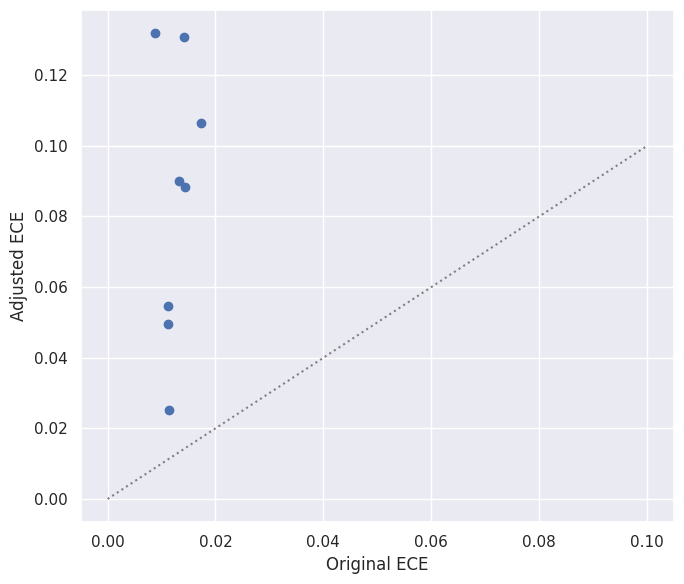

In [25]:
sns.set(style='darkgrid')
plt.figure(figsize=(7, 6))


plt.scatter(ece_values, ece_values_scaling)
plt.plot([0, .1], [0, .1], linestyle=':', color='gray', label='x = y')
plt.xlabel('Original ECE')
plt.ylabel('Adjusted ECE')

plt.tight_layout()
plt.show()

#### Beta Calibration

In [26]:
from netcal.scaling import BetaCalibration
# Loop per class
calibrators = []
marginal_probs_beta = []

for i in range(n_classes):
    beta = BetaCalibration()
    beta.fit(np.array(marginal_probs[i]), np.array(marginal_labels[i]))
    calibrators.append(beta)
    
    probs_transformed = beta.transform(
        np.array(marginal_probs[i])
        )
    marginal_probs_beta.append(probs_transformed)

ModuleNotFoundError: No module named 'netcal'

In [ ]:
# re calculate calibration curve
fig, axs = plt.subplots(n_classes, 2,figsize =(8,12))
for i in range(n_classes):

    prob_true, prob_pred = calibration_curve(
        marginal_labels[i], 
        marginal_probs_beta[i], 
        n_bins = 10,
        strategy='uniform',
        pos_label = 1)


    axs[i,0].hist(marginal_probs_beta[i],bins=15)
    axs[i,0].set_title("Probability distribution: label " + str(i))
    axs[i,1].plot([0, 1], [0, 1], linestyle='--')
    axs[i,1].plot(prob_pred, prob_true, marker='.')
    axs[i,1].set_xlabel("Predicted Probability")
    axs[i,1].set_ylabel("Actual Probability")
    axs[i,1].set_title("Calibration Curve: label " + str(i))

plt.tight_layout()
plt.show()

: 

In [ ]:
ece_values_beta = []
for i in range(n_classes):
    preds = tensor(marginal_probs_beta[i])
    target = tensor(marginal_labels[i])
    
    ece_values_beta.append(metric(preds, target))
print(ece_values)
print(ece_values_scaling)
print(ece_values_beta)

: 

In [ ]:
plt.scatter(list(range(1,6)),ece_values, label = 'Original ECE',alpha =0.5)
plt.scatter(list(range(1,6)),ece_values_scaling, label = 'Scaling ECE',alpha =0.5)
plt.scatter(list(range(1,6)),ece_values_beta, label = 'Beta ECE',alpha =0.5)

plt.legend()
plt.show()


: 